# Fossil Occurence Data Aquisition and Cleaning

In [1]:
options(warn = -1)
library("readr")
library("dplyr")
library("CoordinateCleaner")
library("fossilbrush")
library(janitor)
library(ggplot2)
library('rgplates')
# library('chronosphere')
library("ggplot2") # plotting
library("patchwork") # makes subplots with gg objects
library('tidyr')
library(sf)
library(jpeg)

options(repr.plot.width = 20, repr.plot.height = 10)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Attaching package: 'janitor'


The following objects are masked from 'package:stats':

    chisq.test, fisher.test


Loading required package: sf

Linking to GEOS 3.12.2, GDAL 3.9.3, PROJ 9.4.1; sf_use_s2() is TRUE



In [5]:
# define events by stage boundary
lome = "Katian,Hirnantian"
kw = "Frasnian,Famennian"
pt = "Changhsingian,Induan"
tj= "Rhaetian,Hettangian"
kpg = "Maastrichtian,Danian"

# create download link
query<-paste0("https://paleobiodb.org/data1.2/occs/list.csv?datainfo&rowcount&base_name=","&interval=", kpg, "&show=full")

# dowload and save raw occurences into csv

download.file(query, destfile = "data_files/kpg_occurences.csv", mode = "wb")

# data <-read.csv(file = 'data_files/lome_occurences.csv', skip= 17, header =TRUE) # this should remain the same structure

# head(data)
# colnames(data)

In [8]:
classes<-data %>% 
  group_by(phylum) %>% 
  summarise(unique_classes = list(unique(class)))
# classes
# View(as.data.frame(classes)) # jupyter notebook apparentlydoesn't likeprinting summaries

phylum,unique_classes
<chr>,<list>
,
Annelida,"Polychaeta , NO_CLASS_SPECIFIED,"
Arthropoda,"Trilobita , Ostracoda , Malacostraca , Artiopoda , NO_CLASS_SPECIFIED, Nektaspidida , Xiphosura , , Megacheira"
Brachiopoda,"Lingulata , Rhynchonellata , , Strophomenata , Craniata , NO_CLASS_SPECIFIED, Chileata , Paterinata"
Bryozoa,"Stenolaemata , Gymnolaemata , , NO_CLASS_SPECIFIED"
Chaetognatha,NO_CLASS_SPECIFIED
Chlorophyta,"Ulvophyceae , Chlorophyceae"
Chordata,"Conodonta , NO_CLASS_SPECIFIED, Thelodonti , Agnatha , Pteraspidomorpha , Osteichthyes"
Cnidaria,"Hydrozoa , Anthozoa , Scyphozoa,"


I am going to keep only macrofossils with shelly bits and marine occurrences. Also will remove any unnecessary columns. There are lots of no_class specified so hopefully matching up with Order will work.

In [5]:
# environments to keep in all datasets
marine_enviro<-c("carbonate indet.", "marine indet.", 
                            "deep subtidal shelf", 
                            "lagoonal/restricted shallow subtidal", 
                            "perireef or subreef", "offshore", 
                            "offshore indet.", "basinal (siliceous)",
                            "peritidal", "deep-water indet.", "offshore ramp",
                            "shallow subtidal indet.", "offshore shelf",
                            "basinal (carbonate)", "open shallow subtidal", 
                            "deep subtidal indet.", "lagoonal", 
                            "coastal indet.", "slope", 
                            "platform/shelf-margin reef",
                            "intrashelf/intraplatform reef", "shoreface", 
                            "deep subtidal ramp", "slope/ramp reef")

#phyla to keep in all datasets
phyla <- c("Porifera", "Cnidaria", "Echinodermata", "Mollusca", "Bryozoa", "Brachiopoda", "Chordata", "Arthropoda")

# columns to keep for all files 
entries<-c("occurrence_no","early_interval","ex", "fadlad", 
                  "accepted_name","lat","lng","phylum","class","order","family",
                  "paleolat","paleolng","environment", "life_habit", "ecospace_comments")


In [9]:
path <- "data_files"

files_list <- list.files(path = path, pattern ='*.csv')
print(files_list)


[1] "kpg_occurences.csv"  "kw_occurences.csv"   "lome_occurences.csv"
[4] "pt_occurences.csv"   "tj_occurences.csv"  


In [17]:
# loop to process all datafiles simultaneously

clean_occs <- list()

for (file in seq_along(files_list)) {

    #--------read in data file
    filepath <-paste0(path, "/", files_list[file])
    data = read.csv(filepath, skip= 17, header =TRUE)
    data_copy <- data

    cl <- cc_val(data_copy, value = "flagged", lat="paleolat", lon  ="paleolng") #flags incorrect coordinates
    cl_rec <- data_copy[!cl,] #extract and check them
  
    data_copy <- data_copy %>% cc_val(lat = "paleolat", lon="paleolng") #remove them
 
    # Use fossilbrush to clean taxonomic errors
    b_ranks <- c("phylum", "class", "order", "family", "accepted_name") #accepted_name is genus name
    
    b_suff = list(NULL, NULL, NULL, NULL, c("ina", "ella", "etta"))
    
    data2 <- check_taxonomy(data_copy, suff_set = b_suff, ranks = b_ranks, verbose = FALSE,
                             clean_name = TRUE, resolve_duplicates = TRUE, jump = 5)
    # resolves homonyms, and jump refers to which taxonomic rank is the highest we resolve to. jump = 5 will stop before phylum since phylum level usually has little error.
    
    data_cleaned <- data2$data[1:nrow(data_copy),] 
    
    #-----------extinct at stage boundary?
    interval.ma  <- data_cleaned %>% group_by(early_interval) %>% summarise(min_ma = min(min_ma))

    names(interval.ma) <-c("early_interval", "interval.ma")
    data_cleaned   <- merge(data_cleaned, interval.ma, by=c("early_interval"))
    
    # Find first and last occurrences and merge back into data frame, using min_ma column
    fadlad <- data_cleaned %>% group_by(accepted_name)  %>% 
      summarise(lad = min(interval.ma))
    
    # Merge fad and lad information into data frame, 
    # If it went extinct at a stage boundary assign, add a column 0 if happy, 1 if bye-bye
    data_cleaned <- merge(data_cleaned, fadlad, by=c("accepted_name"))
    data_cleaned$ex <- 0
    data_cleaned$ex[data_cleaned$interval.ma==data_cleaned$lad] <- 1 

    #---------keep only marine occurrences, certain phyla and select columns
        data_updated <- data_cleaned %>%
          filter(environment %in% marine_enviro,
                 phylum %in% phyla) %>%
          select(any_of(entries))

    clean_occs[[files_list[file]]] <- data_updated

        save_path <- "data_files/cleaned"
        clean_file <- paste0(files_list[file], "_cleaned.csv")
        
        write.csv(data_u, file.path(save_path, clean_file), row.names = FALSE)
}

print("fin")

Testing coordinate validity

Flagged 2353 records.

Testing coordinate validity

Removed 2353 records.

Checking formatting [1/4]



 + cleaning names at rank accepted_name        


Checking spelling   [2/4]

Checking ranks      [3/4]

Checking taxonomy   [4/4]



 + resolving duplicates at rank class       e      


Testing coordinate validity

Flagged 315 records.

Testing coordinate validity

Removed 315 records.

Checking formatting [1/4]



...

 + resolving duplicates at rank class       e      


Testing coordinate validity

Flagged 352 records.

Testing coordinate validity

Removed 352 records.

Checking formatting [1/4]



 + cleaning names at rank accepted_name        


Checking spelling   [2/4]

Checking ranks      [3/4]

Checking taxonomy   [4/4]



 + resolving duplicates at rank class       e      
[1] "fin"


# Reproject paleocoords 


In [68]:
#reconstrut paleocoords

occs<- read.csv("C:/Users/prowa/FRES_Learning_Objective/data_files/cleaned/kpg_occurences.csv_cleaned.csv", header = TRUE)

long<-occs$lng
lat<-occs$lat
coords <- data.frame(lon = long, lat = lat)

paleo_coords <- reconstruct(coords, 75, model = "PALEOMAP", enumerate = TRUE)
# paleo_coords <- cbind(occurence_no = occ_no, paleo_coords)

In [69]:
# Convert to data frame first
paleo_coords <- as.data.frame(paleo_coords)

# Add occurrence_no back
paleo_coords$occurrence_no <- occs$occurrence_no

# Now rename the coordinate columns
names(paleo_coords)[names(paleo_coords) == "paleolong"] <- "paleomap_lng"
names(paleo_coords)[names(paleo_coords) == "paleolat"] <- "paleomap_lat"

# Now merge with occs
occs_merged <- merge(occs, paleo_coords, by = "occurrence_no")

In [53]:
head(occs_merged)

occurrence_no,early_interval,accepted_name,lat,lng,phylum,class,order,family,paleolat,paleolng,environment,life_habit,ecospace_comments,median_ao,median_eo,paleomap_lng,paleomap_lat
<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
10983,Frasnian,Amphipora,53.55000,-113.5,Porifera,Stromatoporoidea,Amphiporida,Amphiporidae,-9.29,-57.56,peritidal,epifaunal,,NA,NA,-41.8094,-10.2608
10984,Frasnian,Archaeogastropoda,53.55000,-113.5,Mollusca,Gastropoda,Archaeogastropoda,,-9.29,-57.56,peritidal,epifaunal,,21.436449,0.32215,-41.8094,-10.2608
10985,Frasnian,Megalodon,53.55000,-113.5,Mollusca,Bivalvia,Megalodontida,Megalodontidae,-9.29,-57.56,peritidal,semi-infaunal,,21.436449,0.32215,-41.8094,-10.2608
10986,Frasnian,Metriophyllum,53.55000,-113.5,Cnidaria,Anthozoa,Stauriida,Metriophyllidae,-9.29,-57.56,shallow subtidal indet.,epifaunal,,9.960159,0.42260,-41.8094,-10.2608
10987,Frasnian,Thamnopora,53.55000,-113.5,Cnidaria,Anthozoa,Favositida,Pachyporidae,-9.29,-57.56,shallow subtidal indet.,epifaunal,,9.960159,0.42260,-41.8094,-10.2608
10988,Frasnian,Archaeogastropoda,53.55000,-113.5,Mollusca,Gastropoda,Archaeogastropoda,,-9.29,-57.56,shallow subtidal indet.,epifaunal,,21.436449,0.32215,-41.8094,-10.2608
10989,Frasnian,Megalodon,53.55000,-113.5,Mollusca,Bivalvia,Megalodontida,Megalodontidae,-9.29,-57.56,shallow subtidal indet.,semi-infaunal,,21.436449,0.32215,-41.8094,-10.2608
10990,Frasnian,Modiomorpha,53.55000,-113.5,Mollusca,Bivalvia,Modiomorphida,Modiomorphidae,-9.29,-57.56,shallow subtidal indet.,epifaunal,BODY SIZE: Data from Cox et al. (1969),21.436449,0.32215,-41.8094,-10.2608
10991,Frasnian,Crinoidea,53.55000,-113.5,Echinodermata,Crinoidea,,,-9.29,-57.56,shallow subtidal indet.,upper-level epifaunal,"LIFE HISTORY: Erect and surficial, non-motile attached, suspension feeder according to Bambach et al (2007); low-upper level tiering according to Bottjer & Ausich (1986); placed in upper-level epifaunal tier.",NA,NA,-41.8094,-10.2608


In [70]:
# occs_merged
write.csv(occs_merged, "C:/Users/prowa/FRES_Learning_Objective/data_files/cleaned/reconstructed/kpg_reconstructed.csv")

# Joining MI

In [3]:
MI <- read.csv("C:/Users/prowa/FRES_Learning_Objective/data_files/MI/MI_traits_Amended.csv", header = TRUE)

MI <- clean_names(MI)

MI$ao_1_atm[MI$ao_1_atm == "#VALUE!"]<-NaN

MI$ao_1_atm<-as.numeric(MI$ao_1_atm)
MI$phi_crit_histogram<-as.numeric(MI$phi_crit_histogram)

MI$phyla<-as.factor(MI$phyla)
# head(MI)

phyla2drop <- c("Nematoda", "Rotifera", "Ctenophora", "Chaetognatha")

MI <- MI %>%
  filter(!phyla %in% phyla2drop)

# MI %>% count(phyla)
MI <- na.omit(MI)


######
sapply(MI, class)
MI[MI == '#VALUE!'] <- NA
num_cols <- c('ao_1_atm', 'eo_e_v', 'phi_crit_histogram')
MI[num_cols] <- lapply(MI[num_cols], function(x) as.numeric(as.character(x)))
MI_clean <- MI[complete.cases(MI[num_cols]), ]
# head(MI_clean)

MI_clean <- MI_clean %>%
  rename('phylum' = 'phyla',
         'ao' = 'ao_1_atm',
         'eo' = 'eo_e_v',
         'Phi_crit' = 'phi_crit_histogram')


orders <- unique(MI_clean$order)
# print(orders)

benthic <- c("Decapoda", "Blenniiformes", "Ostreida", "Littorinimorpha", 
             "Scleractinia", "Pleuronectiformes", "Pectinida", "Stolidobranchia")
pelagic <- orders[!orders %in% benthic]
# pelagic

benthic_fish <- c("Blenniiformes", "Pleuronectiformes", "Stoliodobranchia")
benthic_moll <- c("Ostreida", "Littorinimorpha", "Pectinida")
benthic_arth <- c("Decapoda")


arth <- MI_clean[MI_clean$phylum == "Arthropoda", ]
arth_ben <- arth[arth$order %in% benthic_arth, ]
arth_pel <- arth[!arth$order %in% benthic_arth, ]

moll <- MI_clean[MI_clean$phylum == "Mollusca", ]
moll_ben <- moll[moll$order %in% benthic_moll, ]
moll_pel <- moll[!moll$order %in% benthic_moll, ]

chor <- MI_clean[MI_clean$phylum == "Chordata", ]
chor_ben <- chor[chor$order %in% benthic_fish, ]
chor_pel <- chor[!chor$order %in% benthic_fish, ]

cnid <- MI_clean[MI_clean$phylum == "Cnidaria", ]


print(median(arth$ao, na.rm = TRUE))
print(median(moll_ben$ao, na.rm = TRUE))
print(median(moll_pel$ao, na.rm = TRUE))
print(median(chor_ben$ao, na.rm = TRUE))
print(median(chor_pel$ao, na.rm = TRUE))
print(median(cnid$ao, na.rm = TRUE))

Ao_cnid <- median(cnid$ao, na.rm = TRUE)

assign_life_habit <- function(row) {
  benthic <- c("Decapoda", "Blenniiformes", "Ostreida", "Littorinimorpha", 
               "Scleractinia", "Pleuronectiformes", "Pectinida", "Stolidobranchia")
  
  if (row['order'] %in% benthic) {
    return('benthic')
  } else {
    return('pelagic')
  }
}

MI_clean$habitat <- apply(MI_clean, 1, assign_life_habit)

# get ao,eo,ph medians for pelagic vsbenthic modeof life
habit_stats <- MI_clean %>%
  group_by(habitat) %>%
  summarise(
    ao_med_habit = median(ao, na.rm = TRUE),
    eo_med_habit = median(eo, na.rm = TRUE),
    Phi_crit_med_habit = median(Phi_crit, na.rm = TRUE)
  )
# head(habit_stats)
                       
#get median ao,eo and phi based on taxonomic groups and life habit
tax_stats <- MI_clean %>%
  group_by(order, habitat) %>%
  summarise(
    ao_med_tax = median(ao, na.rm = TRUE),
    eo_med_tax = median(eo, na.rm = TRUE),
    Phi_crit_med_tax = median(Phi_crit, na.rm = TRUE),
    .groups = 'drop'
  )

# tax_stats                       

# # Calculate mean Phi_crit by Phyla
phyla_phi <- MI_clean %>%
  group_by(phylum) %>%
  summarise(Phi_crit = median(Phi_crit, na.rm = TRUE)) %>%
  rename(Phyla_Phi_crit = Phi_crit)

# # Merge with stats dataframe
# # Step 3: Merge back to original dataframe
MI_enriched <- MI_clean %>%
  left_join(tax_stats, by = c('order', 'habitat')) %>%
  left_join(phyla_phi, by = 'phylum')

head(MI_enriched)



id              phyla              order            species 
       "character"           "factor"        "character"        "character" 
          ao_1_atm             eo_e_v phi_crit_histogram          reference 
         "numeric"          "numeric"          "numeric"        "character"

[1] 24.39024
[1] 19.12046
[1] 25.70694
[1] 25.06266
[1] 18.01802
[1] 9.960159


,id,phylum,order,species,ao,eo,Phi_crit,reference,habitat,ao_med_tax,eo_med_tax,Phi_crit_med_tax,Phyla_Phi_crit
,<chr>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,158347,Arthropoda,Decapoda,'Acanthephyra acutifrons',26.80965,-0.0278,2.0060,'Cowles ea '91 MarBiol 110: 75-83',benthic,24.09988,0.3128,2.84695,2.79510
2,107579,Arthropoda,Decapoda,'Acanthephyra curtirostris',25.57545,0.0380,1.7805,'Childress '75 CBP 50A: 787-799',benthic,24.09988,0.3128,2.84695,2.79510
3,107582,Arthropoda,Decapoda,'Acanthephyra purpurea',23.31002,0.1320,3.1243,'Donnelly & Torres '88 MarBiol 97: 483-494',benthic,24.09988,0.3128,2.84695,2.79510
4,210432,Arthropoda,Decapoda,'Acanthephyra smithi',28.98551,-0.0301,1.6415,'Cowles ea '91 MarBiol 110: 75-83',benthic,24.09988,0.3128,2.84695,2.79510
5,157869,Chordata,Acipenseriformes,'Acipenser brevirostrum',22.12389,0.3626,4.5135,"'Campbell and Goodman, 2004'",pelagic,22.12389,0.3626,4.51350,2.91755
6,271705,Chordata,Anguilliformes,'Anguilla japonica',7.89266,0.1266,1.3225,"'Chan, D. K., & Woo, N. Y. (1978). Effect of cortisol on the metabolism of the …'",pelagic,7.89266,0.1266,1.32250,2.91755


In [54]:
occs <- read.csv("C:/Users/prowa/FRES_Learning_Objective/data_files/cleaned/reconstructed/kpg_reconstructed.csv")
print(colnames(occs))
print(colnames(MI_enriched))

orders <- MI_enriched %>% distinct(order)

assign_habitat <- function(row) {
  pelagic_habitat <- c('nektonic', 'nektonic, solitary', 'planktonic', 'planktonic, solitary')
  
  if (row['life_habit'] %in% pelagic_habitat) {
    return('pelagic')
  } else {
    return('benthic')
  }
}

occs$habitat <- apply(occs, 1, assign_habitat)

cols2keep <- c('phylum', 'order', 'habitat',	'ao_med_tax',	'eo_med_tax',	'Phi_crit_med_tax',	'Phyla_Phi_crit')
MI_enriched_sub <- MI_enriched[, cols2keep]

occs_MI <- occs %>%
  left_join(MI_enriched_sub, by = c("phylum", 'habitat'))

# head(occs_MI)
# because there is no brachiopod MI data assign then the median of all benthics
benthic_stats <- MI_clean %>%
  group_by(habitat) %>%
  summarise(
    ao = median(ao, na.rm = TRUE),
    eo = median(eo, na.rm = TRUE),
    Phi_crit = median(Phi_crit, na.rm = TRUE)
  )

benthic_stats

benthic_ao <- benthic_stats[benthic_stats$habitat == 'benthic', 'ao']
benthic_eo <- benthic_stats[benthic_stats$habitat == 'benthic', 'eo']
benthic_phi <- benthic_stats[benthic_stats$habitat == 'benthic', 'Phi_crit']

occs_MI$ao_med_tax[occs_MI$phylum == 'Brachiopoda'] <- benthic_ao
occs_MI$eo_med_tax[occs_MI$phylum == 'Brachiopoda'] <- benthic_eo
occs_MI$Phi_crit_med_tax[occs_MI$phylum == 'Brachiopoda'] <- benthic_phi
occs_MI$Phyla_Phi_crit[occs_MI$phylum == 'Brachiopoda'] <- benthic_phi

head(occs_MI)

occs_MI[]<-lapply(occs_MI, function(x) if(is.list(x)) as.numeric(x) else x)
write.csv(occs_MI, "C:/Users/prowa/FRES_Learning_Objective/data_files/cleaned/reconstructed/joined/kpg_occs_MI.csv", row.names = FALSE)

# # merge MI['Phyla_Phi_crit'] into occs by phylum 
 
# # merge MI['PHi_crit_median'] into occs by phy

 [1] "X"                 "occurrence_no"     "early_interval"   
 [4] "interval.ma"       "lad"               "accepted_name"    
 [7] "lat"               "lng"               "ex"               
[10] "phylum"            "class"             "order"            
[13] "family"            "paleolat"          "paleolng"         
[16] "environment"       "life_habit"        "ecospace_comments"
[19] "paleomap_lng"      "paleomap_lat"     
 [1] "id"               "phylum"           "order"            "species"         
 [5] "ao"               "eo"               "Phi_crit"         "reference"       
 [9] "habitat"          "ao_med_tax"       "eo_med_tax"       "Phi_crit_med_tax"
[13] "Phyla_Phi_crit"  


habitat,ao,eo,Phi_crit
<chr>,<dbl>,<dbl>,<dbl>
benthic,23.20236,0.32145,2.84695
pelagic,21.81464,0.32445,2.93500


,X,occurrence_no,early_interval,interval.ma,lad,accepted_name,lat,lng,ex,phylum,⋯,life_habit,ecospace_comments,paleomap_lng,paleomap_lat,habitat,order.y,ao_med_tax,eo_med_tax,Phi_crit_med_tax,Phyla_Phi_crit
,<int>,<int>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<int>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<list>,<list>,<list>,<list>
1,1,14961,Maastrichtian,56,56,Nucula percrassa,37,-89.86667,1,Mollusca,⋯,infaunal,,-60.7154,41.941,benthic,Ostreida,13.1406,0.2151,2.4537,3.13865
2,1,14961,Maastrichtian,56,56,Nucula percrassa,37,-89.86667,1,Mollusca,⋯,infaunal,,-60.7154,41.941,benthic,Littorinimorpha,19.12046,0,3.9362,3.13865
3,1,14961,Maastrichtian,56,56,Nucula percrassa,37,-89.86667,1,Mollusca,⋯,infaunal,,-60.7154,41.941,benthic,Pectinida,21.36752,0.304,4.3829,3.13865
4,2,14962,Maastrichtian,56,56,Malletia,37,-89.86667,1,Mollusca,⋯,infaunal,,-60.7154,41.941,benthic,Ostreida,13.1406,0.2151,2.4537,3.13865
5,2,14962,Maastrichtian,56,56,Malletia,37,-89.86667,1,Mollusca,⋯,infaunal,,-60.7154,41.941,benthic,Littorinimorpha,19.12046,0,3.9362,3.13865
6,2,14962,Maastrichtian,56,56,Malletia,37,-89.86667,1,Mollusca,⋯,infaunal,,-60.7154,41.941,benthic,Pectinida,21.36752,0.304,4.3829,3.13865


In [35]:
path <- "data_files/cleaned"
files_list <- list.files(path = path, pattern ='*.csv')

for (file in seq_along(files_list)) {
    #--------read in data file
    filepath <- paste0(path, "/", files_list[file])
    # print(filepath)
    data = read.csv(filepath, header = TRUE)
    
    # Clean column names by removing whitespace
    colnames(data) <- trimws(colnames(data))
    colnames(avgs) <- trimws(colnames(avgs))  # Do this once outside the loop if avgs doesn't change
    
    # print(colnames(data))
    
    data.joined <- full_join(data, avgs, by = 'phylum')
    print(colnames(data.joined))
    save_path <- "data_files/cleaned/joined"
    clean_file <- paste0(files_list[file], "_joined.csv")
        
    write.csv(data.joined, file.path(save_path, clean_file), row.names = FALSE)
}

 [1] "occurrence_no"     "early_interval"    "interval.ma"      
 [4] "lad"               "accepted_name"     "lat"              
 [7] "lng"               "ex"                "phylum"           
[10] "class"             "order"             "family"           
[13] "paleolat"          "paleolng"          "environment"      
[16] "life_habit"        "ecospace_comments" "median_ao"        
[19] "median_eo"        
 [1] "occurrence_no"     "early_interval"    "interval.ma"      
 [4] "lad"               "accepted_name"     "lat"              
 [7] "lng"               "ex"                "phylum"           
[10] "class"             "order"             "family"           
[13] "paleolat"          "paleolng"          "environment"      
[16] "life_habit"        "ecospace_comments" "median_ao"        
[19] "median_eo"        
 [1] "occurrence_no"     "early_interval"    "interval.ma"      
 [4] "lad"               "accepted_name"     "lat"              
 [7] "lng"               "ex"           

# Plotting 

In [27]:
library(patchwork)

ao<- ggplot(MI, aes(x = ao_1_atm, fill = phyla)) +
  geom_histogram(bins = 30) +
  facet_wrap(~ phyla, scales = "free_y")

eo<- ggplot(MI, aes(x = eo_e_v, fill = phyla)) +
  geom_histogram(bins = 30) +
  facet_wrap(~ phyla, scales = "free_y")

combo<-ao+ eo+
plot_layout(guides = "collect")&
theme(legend.position = 'bottom')

ggsave("MI_dist.png", combo)
# all echinodermata has nan values, there is only on porifera

Saving 7 x 7 in image


In [18]:
# this takes forever to run so I saved all of the output as .shp files

# library('rgplates')
# library('chronosphere')
# 
# td <-tempdir() #temporary directory
# 
# #unzip(file.path(system.file(package="rgplates"), "extdata/paleomap_v3.zip"), exdir=tempdir())
# rgPath <- system.file(package="rgplates")
# 
# unzip(file.path(rgPath, "extdata/paleomap_v3.zip"), exdir=td)
# 
# 
# pathToPolygons <- file.path(td, "PALEOMAP_PlatePolygons.gpml") #static plate polygons
# pathToRotations <- file.path(td, "PALEOMAP_PlateModel.rot")
# 
# pm <- platemodel(
#   features = c("coastlines" = pathToPolygons),
#   rotation = pathToRotations
# )
# 
# #https://rdrr.io/cran/rgplates/src/R/offline.R
# #C:\Program Files\gplates_2.5.0_win64
# 
# ##### MAKE SURE YOU ASSIGN AGE HERE ##### Must be age from rGPlates 
# 
# edge <-mapedge() #edge of the map
# plates.pt<- reconstruct("coastlines",# or coastlines 
#                         age= 440, 
#                         model =pm, 
#                         path.gplates ="/Users/prowa/gplates_2.5.0_win64/gplates") 
# 
# saveRDS(edge, "C:/Users/prowa/FRES_Learning_Objective/data_files/georeferenced_files/edge_lome.rds")
# saveRDS(plates.pt, "C:/Users/prowa/FRES_Learning_Objective/data_files/georeferenced_files/plates._lome.rds")


# # coastlines <- fetch(src = "paleomap", ser = "paleocoastlines")
# coast_slice <- coastlines[[39]]

# #save relevant time slice locally 
# # 
# st_write(coast_slice, "C:/Users/prowa/FRES_Learning_Objective/data_files/georeferenced_files/coastlines_250Ma.shp", delete_dsn = TRUE)
# # 
# # # Or save as RDS for fast re-load
# saveRDS("C:/Users/prowa/FRES_Learning_Objective/data_files/georeferenced_files/coastlines_250Ma.shp", "C:/Users/prowa/FRES_Learning_Objective/data_files/georeferenced_files/coastlines_250Ma.rds")
# # 


Loading required package: sf

Linking to GEOS 3.12.2, GDAL 3.9.3, PROJ 9.4.1; sf_use_s2() is TRUE



ERROR: Error in gzfile(file, "rb"): cannot open the connection


In [77]:
plates.pt <- readRDS("data_files/georeferenced_files/plates._lome.rds")  # or use the object directly
edge <- readRDS("data_files/georeferenced_files/edge_lome.rds")  # not required for plotting unless you're doing map framing

# coast_slice <- readRDS("data_files/georeferenced_files/coastlines_65Ma.shp") # closest timeslice to time interval of interest
# coast_sf <- st_as_sf(coast_slice)

coast_sf <- st_read("data_files/georeferenced_files/coastlines_440Ma.shp")
event <- read.csv("C:/Users/prowa/FRES_Learning_Objective/data_files/cleaned/joined/reconstructed/lome_event.csv", header = TRUE)

event_all<- event %>% drop_na(paleomap_lat, paleomap_lng)
event_MI<- event %>% drop_na(paleomap_lat, paleomap_lng, median_ao, median_eo)

points_event <- st_as_sf(event_all, coords = c("paleomap_lng", "paleomap_lat"), crs = 4326) # rectangular grid
points_MI <- st_as_sf(event_MI, coords = c("paleomap_lng", "paleomap_lat"), crs = 4326) # rectangular grid

#transform it to projection, here rectagular 
points_event <- sf::st_transform(points_event, crs = st_crs(plates.pt))
points_MI<-sf::st_transform(points_MI, crs = st_crs(plates.pt))


# Transform plate boundaries to Robinson projection
# platesRob <- sf::st_transform(plates.pt, "ESRI:54030")
# coast_sf <- sf::st_transform(coast_sf , crs = "ESRI:54030")

#use equirectangular projection for baselayer
platesRob <- sf::st_transform(plates.pt, crs = 4326)
coast_sf <- sf::st_transform(coast_sf , crs = 4326)


pointsRob_all <- sf::st_transform(points_event, crs = 4326) # recta
pointsRob_MI <- sf::st_transform(points_MI, crs = 4326)



Reading layer `coastlines_440Ma' from data source 
  `C:\Users\prowa\FRES_Learning_Objective\data_files\georeferenced_files\coastlines_440Ma.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 31 features and 1 field
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: -90 xmax: 180 ymax: 42.72353
Geodetic CRS:  WGS 84


In [ ]:
# plot colored by phyl
phyla_occs<-ggplot() +
  geom_sf(data = coast_sf, fill = "gray90", color = "black", size = 0.3) +
  geom_sf(data = pointsRob_all, aes(color = phylum), size = 0.5, alpha = 0.5) +
  coord_sf(crs = st_crs(platesRob)) +
  theme_minimal() +
  labs(
    # title = "LOME",
    color = "Phylum"
  )

ext_occs <- ggplot() +
  geom_sf(data = coast_sf, fill = "gray90", color = "black", size = 0.3) +
  geom_sf(
    data = pointsRob_MI,
    aes(color = factor(median_ao), shape = factor(phylum)),
    size = 0.5,
    alpha = 0.5
  )+ 

  coord_sf(crs = st_crs(platesRob)) +
  theme_minimal() +
  labs(
    # title = "Fossil Occurrences on Devonian Paleogeography",
    color = "Hypoxia Tolerance"
  )

combo <- phyla_occs / ext_occs
combo
# ggsave("Figures/kpg_coastlines.png", combo, width = 8, height = 6, dpi = 300)

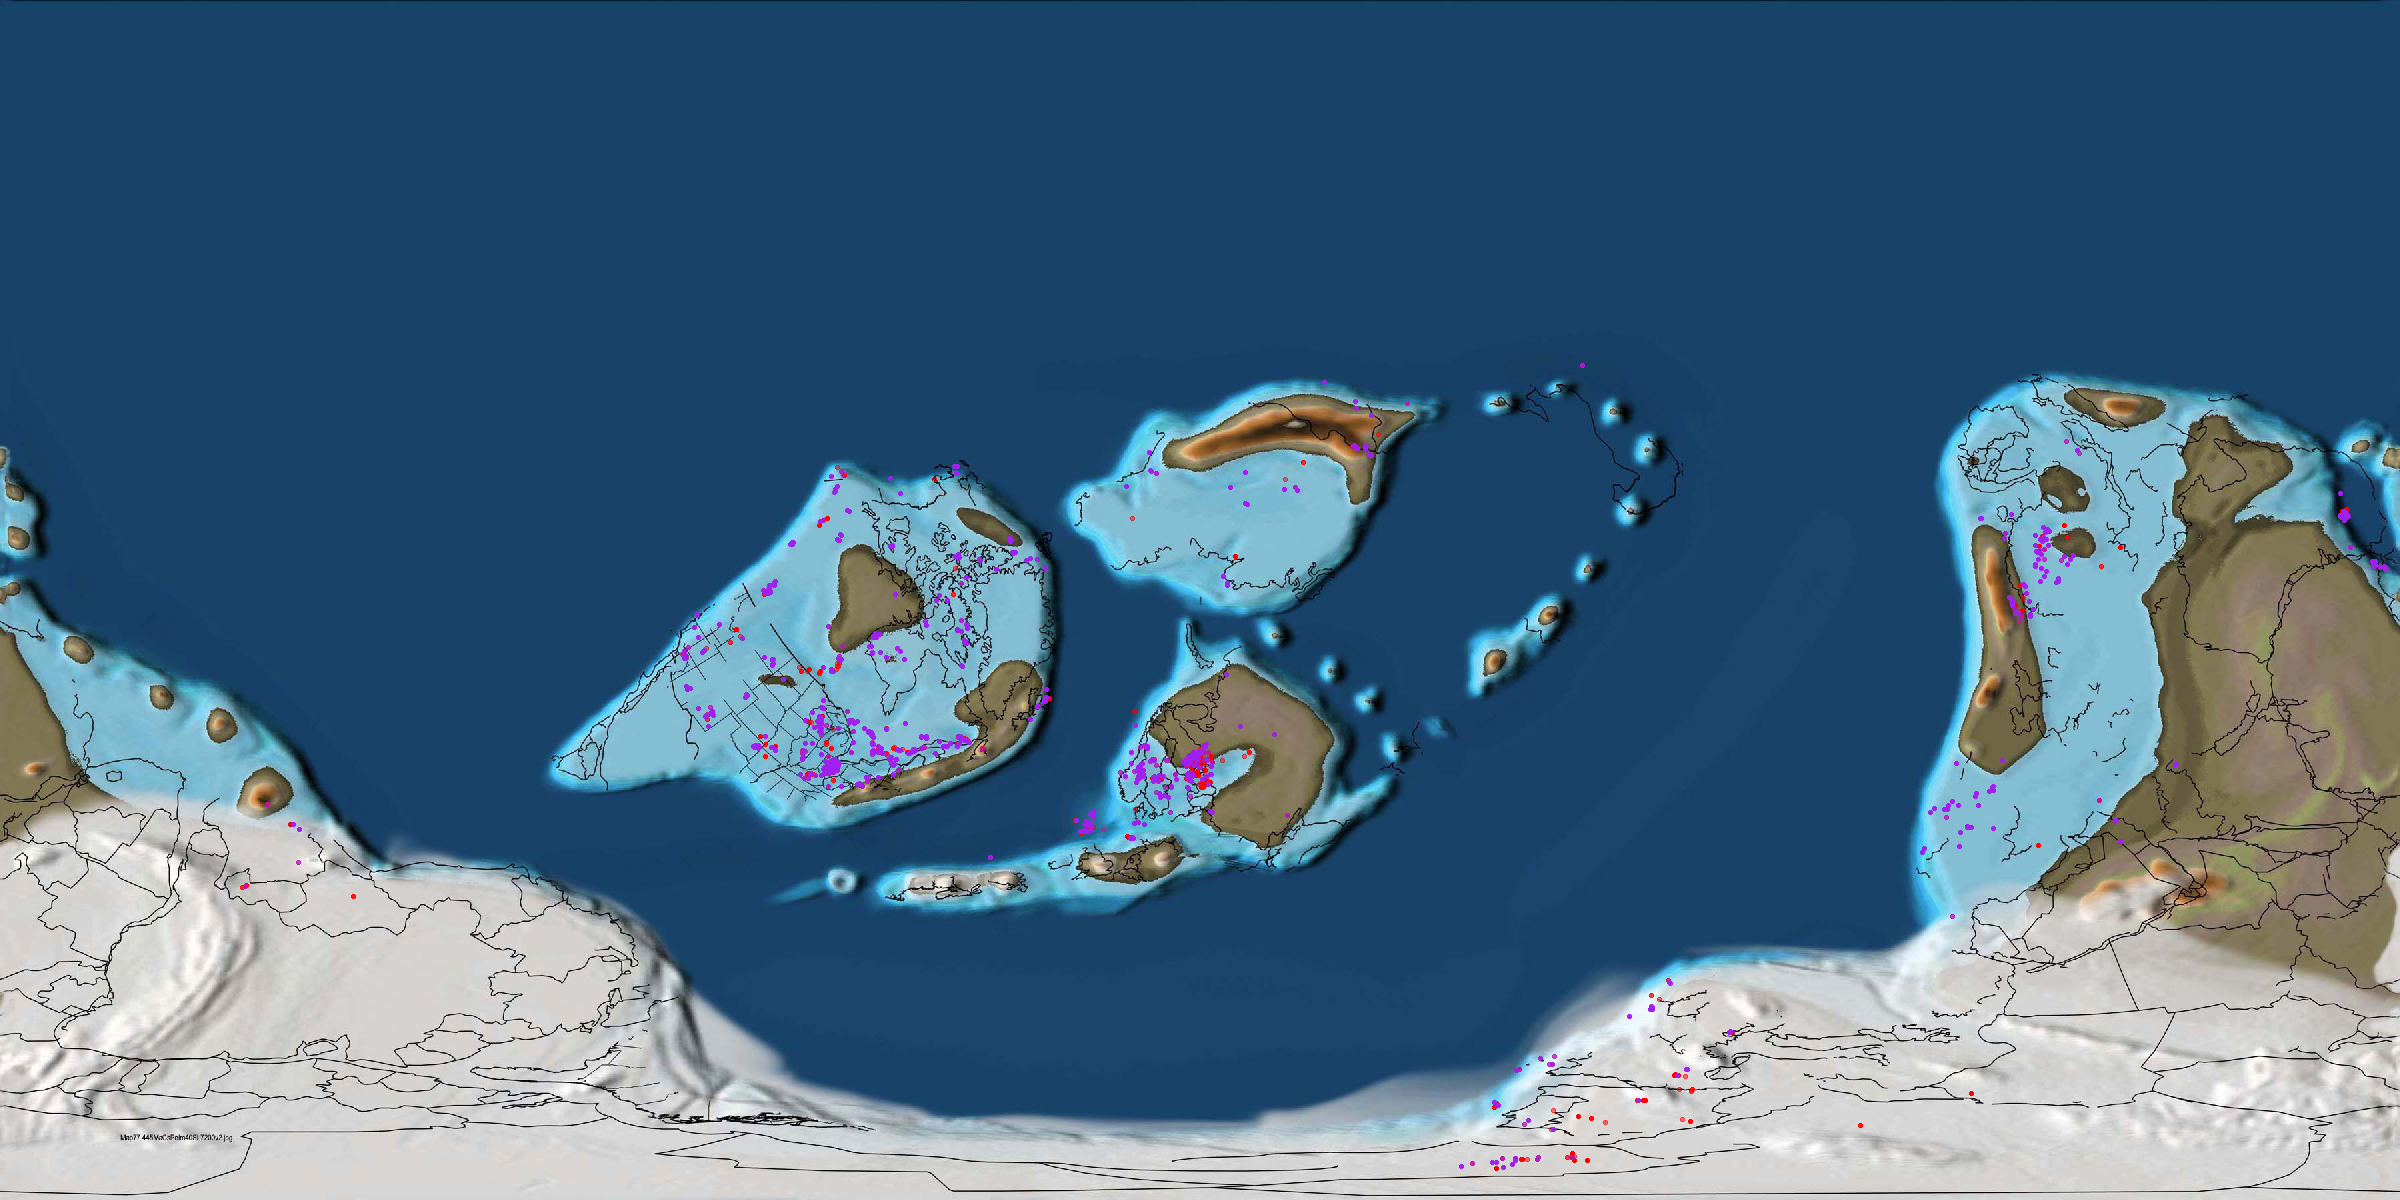

In [79]:
# Read your JPG
# jpg_img <- readJPEG("C:/Users/prowa/FRES_Learning_Objective/data_files/georeferenced_files/Rasters/Map18a LtK Late Campanian_075.jpg")
# jpg_img <-readJPEG("C:/Users/prowa/FRES_Learning_Objective/data_files/georeferenced_files/Rasters/Map66a LtD Famennian_370.jpg")
# jpg_img <-readJPEG("C:/Users/prowa/FRES_Learning_Objective/data_files/georeferenced_files/Rasters/Map43a Triassic-Jurassic Boundary_200.jpg")
# jpg_img <-readJPEG("C:/Users/prowa/FRES_Learning_Objective/data_files/georeferenced_files/Rasters/Map49a Permo-Triassic Boundary_250.jpg")

jpg_img <-readJPEG("C:/Users/prowa/FRES_Learning_Objective/data_files/georeferenced_files/Rasters/Map77a LtO Hirnantian_445.jpg")

# Create the plot with proper alignment
occs<-ggplot() +
  # Add JPG as background (full world extent)
  annotation_raster(
    jpg_img,
    xmin = -180, xmax = 180,
    ymin = -90, ymax = 90
  ) +
  # Overlay your spatial data (in order of layering)
  # geom_sf(data = coast_sf, fill = NA, color = "black", linewidth = 0.5) +
  # geom_sf(data = platesRob, fill = NA, color = "red", linewidth = 0.3) +
  geom_sf(data = pointsRob_all, color = "red", size = 1, alpha = 0.5) +
  geom_sf(data = pointsRob_MI, color = "purple", size = 1, alpha = 0.5) +
  # Set coordinate system and limits
  coord_sf(xlim = c(-180, 180), ylim = c(-90, 90), 
           crs = 4326, expand = FALSE) +
  theme_void()

occs
s
ggsave("Figures/pt_250Ma.png", occs, width = 8, height = 6, dpi = 300)

In [81]:
ggsave("Figures/lome_440Ma.png", occs, width = 8, height = 6, dpi = 300)

Potential options so fossil occurences match better.
Rerotate lat and long of occurrences using a different plate model, reproject to mollweide and use those rasters. 


In [5]:
library(robis)


Attaching package: 'robis'


The following object is masked from 'package:patchwork':

    area




In [14]:
occ <- occurrence("Pecten maximus")

Retrieved 5000 records of approximately 10726 (46%)
Retrieved 10000 records of approximately 10726 (93%)
Retrieved 10726 records of approximately 10726 (100%)


In [13]:
colnames(occ)


[1] "accessRights"                   "basisOfRecord"                 
  [3] "brackish"                       "catalogNumber"                 
  [5] "class"                          "classid"                       
  [7] "collectionCode"                 "collectionID"                  
  [9] "coordinateUncertaintyInMeters"  "country"                       
 [11] "datasetName"                    "day"                           
 [13] "decimalLatitude"                "decimalLongitude"              
 [15] "family"                         "familyid"                      
 [17] "genus"                          "genusid"                       
 [19] "gigaclass"                      "gigaclassid"                   
 [21] "individualCount"                "infraphylum"                   
 [23] "infraphylumid"                  "institutionCode"               
 [25] "kingdom"                        "kingdomid"                     
 [27] "license"                        "marine"                        
 [29] "modified"                       "month"                         
 [31] "occurrenceID"                   "order"                         
 [33] "orderid"                        "ownerInstitutionCode"          
 [35] "parvphylum"                     "parvphylumid"                  
 [37] "phylum"                         "phylumid"                      
 [39] "recordNumber"                   "recordedBy"                    
 [41] "rightsHolder"                   "scientificName"                
 [43] "scientificNameID"               "species"                       
 [45] "speciesid"                      "subphylum"                     
 [47] "subphylumid"                    "superclass"                    
 [49] "superclassid"                   "taxonID"                       
 [51] "type"                           "verbatimDepth"                 
 [53] "year"                           "id"                            
 [55] "dataset_id"                     "node_id"                       
 [57] "dropped"                        "absence"                       
 [59] "originalScientificName"         "aphiaID"                       
 [61] "flags"                          "bathymetry"                    
 [63] "shoredistance"                  "sst"                           
 [65] "sss"                            "bibliographicCitation"         
 [67] "datasetID"                      "date_end"                      
 [69] "date_mid"                       "date_start"                    
 [71] "date_year"                      "depth"                         
 [73] "eventDate"                      "eventID"                       
 [75] "footprintWKT"                   "locality"                      
 [77] "minimumDepthInMeters"           "occurrenceStatus"              
 [79] "parentEventID"                  "samplingProtocol"              
 [81] "scientificNameAuthorship"       "specificEpithet"               
 [83] "taxonRank"                      "taxonomicStatus"               
 [85] "verbatimIdentification"         "geodeticDatum"                 
 [87] "language"                       "lifeStage"                     
 [89] "maximumDepthInMeters"           "vernacularName"                
 [91] "fieldNotes"                     "eventRemarks"                  
 [93] "eventTime"                      "locationRemarks"               
 [95] "maximumElevationInMeters"       "minimumElevationInMeters"      
 [97] "references"                     "samplingEffort"                
 [99] "stateProvince"                  "taxonRemarks"                  
[101] "verbatimLocality"               "waterBody"                     
[103] "informationWithheld"            "occurrenceRemarks"             
[105] "sex"                            "continent"                     
[107] "countryCode"                    "dynamicProperties"             
[109] "endDayOfYear"                   "establishmentMeans"            
[111] "fieldNumber"                    "ge

[1] NA NA

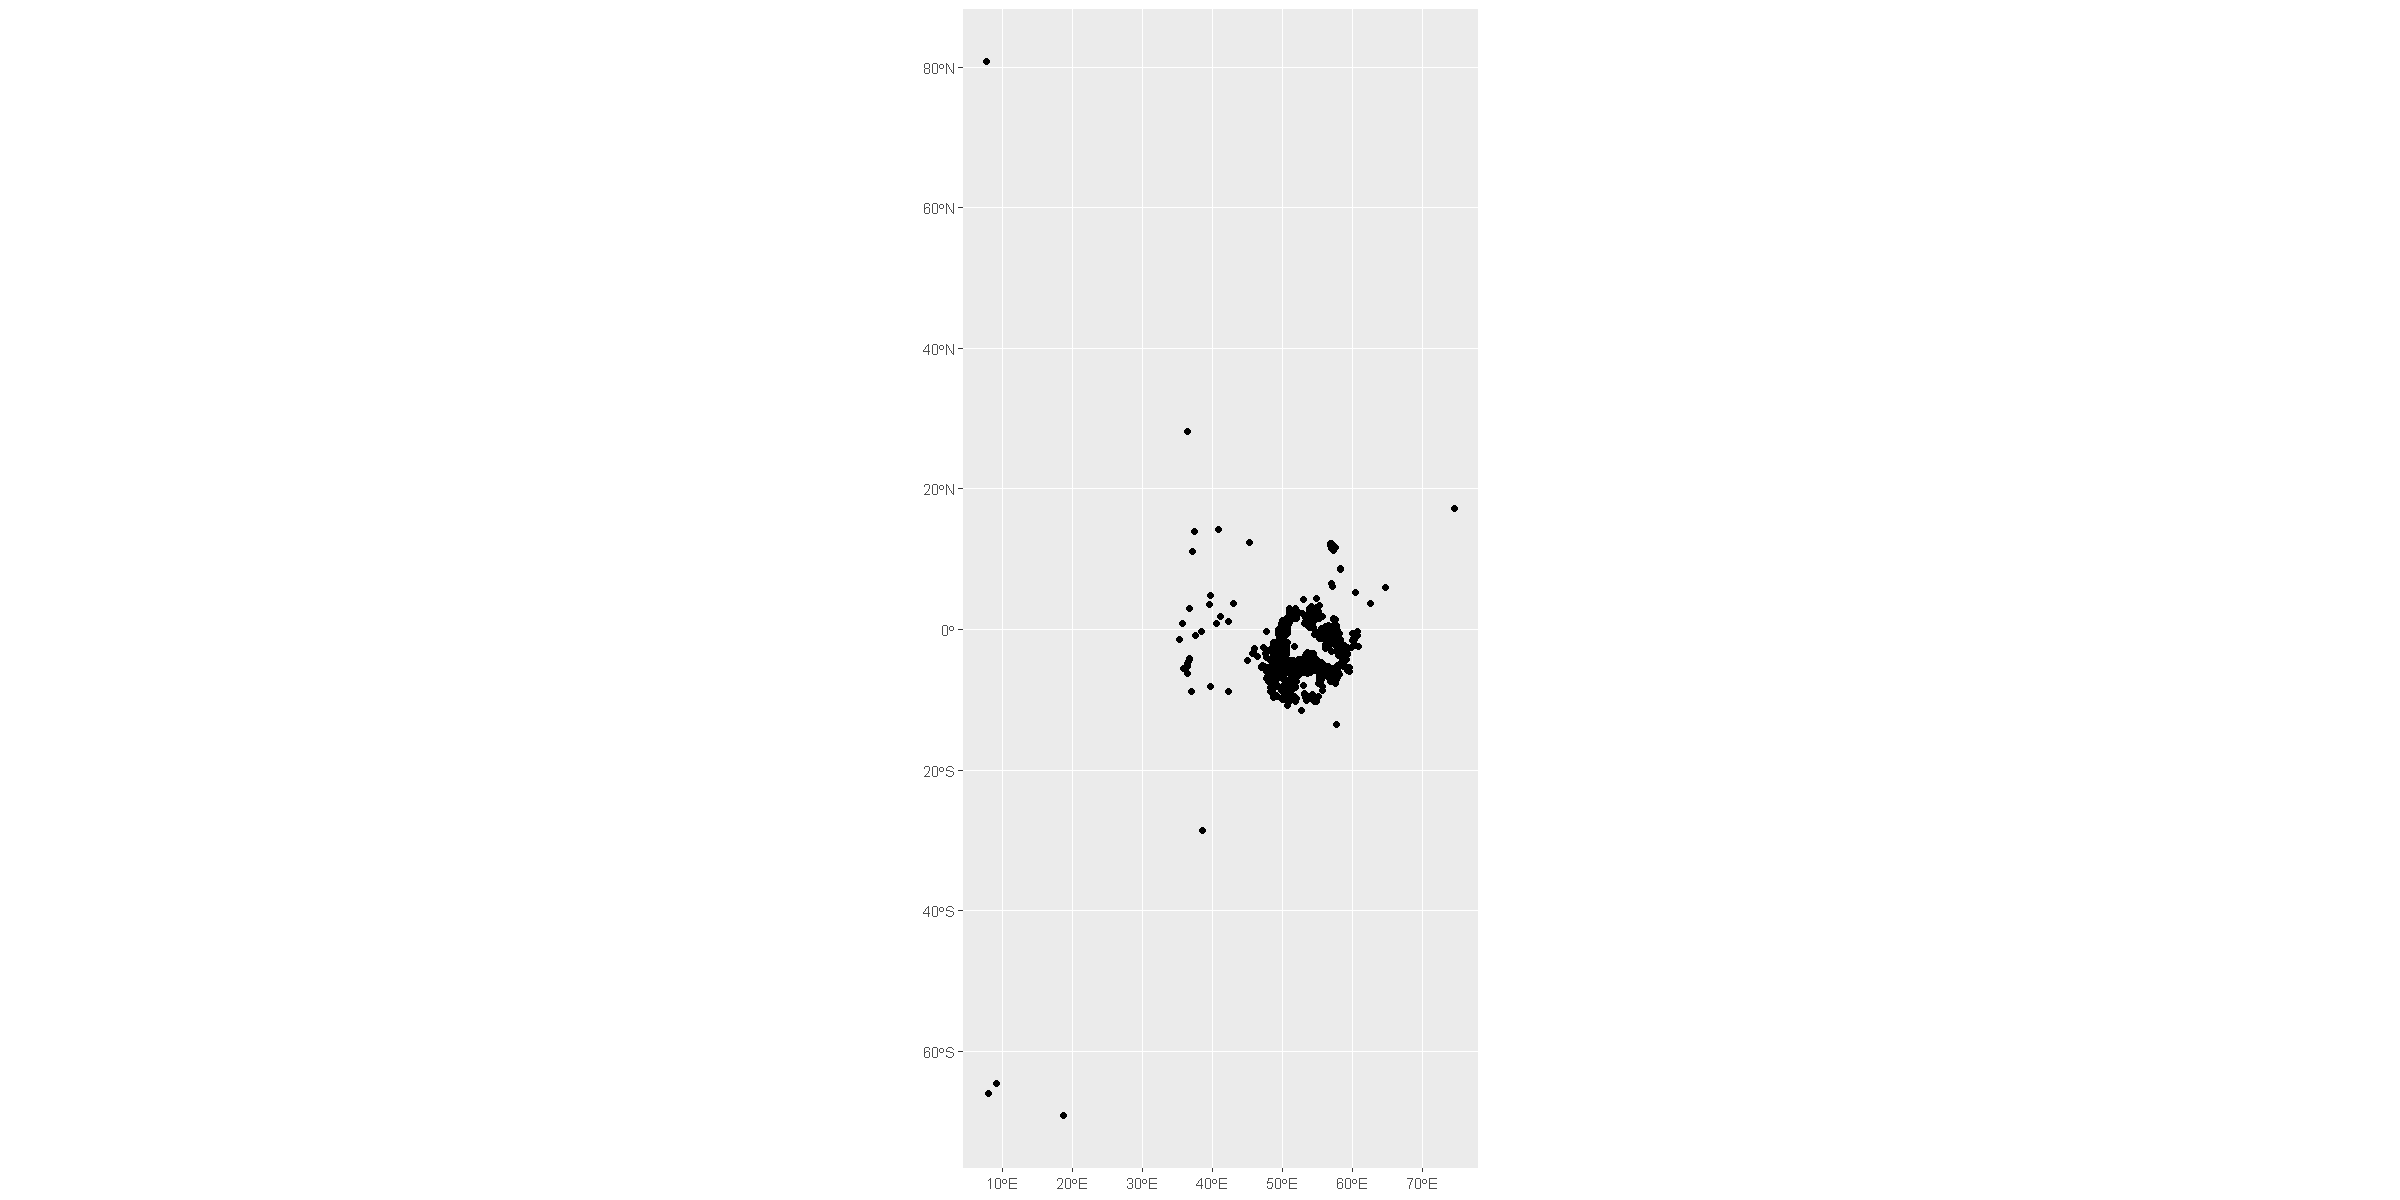

In [16]:
library("ggplot2")

coords <- data.frame(decimalLatitude = occ$decimalLatitude, decimalLongitude = occ$decimalLongitude)
coords_sf <- st_as_sf(coords, coords = c("decimalLatitude", "decimalLongitude"), crs = 4326)

write_csv(coords, "Pecten maximus.csv")

ggplot() +
geom_sf(data = coords_sf)